# Análisis de Sentimientos: Comentarios sobre Obesidad

Este notebook explora los sentimientos en comentarios relacionados con obesidad clasificados con vLLM y Llama-3.2-3B-Instruct.

## Objetivos del Análisis:
1. **Distribución de sentimientos** - Visualizar la proporción de comentarios positivos, negativos y neutros
2. **Palabras más frecuentes** - Identificar términos comunes por cada categoría de sentimiento
3. **Análisis TF-IDF** - Encontrar las palabras más significativas y distintivas de cada grupo
4. **Identificación de insultos** - Detectar y analizar las expresiones ofensivas más frecuentes
5. **Relación longitud-sentimiento** - Analizar si la extensión de los comentarios se relaciona con el sentimiento
6. **Patrones temporales** - Explorar distribución temporal y engagement

---

Realizamos también una clasificación de sentimiento utilizando un LLM, llama3.2 8B Instruct. La prompt que utilizamos fue la siguiente:

```
Eres un experto en análisis de sentimientos. Tu tarea es clasificar el sentimiento de comentarios relacionados con obesidad y peso corporal.

Instrucciones:
- Clasifica el sentimiento como: POSITIVO, NEGATIVO, o NEUTRO
- POSITIVO: comentarios que expresan apoyo, comprensión, motivación o actitudes constructivas hacia personas con obesidad
- NEGATIVO: comentarios que expresan discriminación, burla, odio, desprecio o actitudes destructivas hacia personas con obesidad  
- NEUTRO: comentarios informativos, descriptivos o sin carga emocional clara

Responde únicamente con una de estas tres palabras: POSITIVO, NEGATIVO, NEUTRO<|eot_id|><|start_header_id|>user<|end_header_id|>

Comentario a clasificar: "{comment}"
```

Hicimos por ahora una revisión cualitativa y encontramos casos como:
- "Rapa Nui engorda." -> Casos que podrían ser considerados neutrales clasificados como negativos, que consideramos mal clasificados.
- "Vuelo 28 de enero a BsAs. Problemas en el counter de santiago. Quien hace ni chequeo me da una tarjeta de embarque a otro nombre ,me cobra 4 k sobrepeso y no me da Tíbet de maleta. Mi maleta no llega a Bs As. Nadie se hace cargo. Quien responde x mi perdida???" -> Otros que sí son negativos pero que no se relacionan con la temática, aunque se encontraron pocos de estos casos. Estos también están mal clasificados.
- "Necesito dejar de seguir a la chica del brunch o voy a terminar obesa y pobre" -> Comentarios que si bien no son insultos, sí manifiestan una percepción o postura negativa hacia la gordura.
- "Eso por hacerle caso al obeso estrogenado ese xD" -> La inmensa mayoría son insultos, o comentarios donde la palabra "obeso/a" forma parte de un insulto más largo.

Obtenemos una distribución de sentimiento similar a la observada con pysentimiento. En esta clasificación el porcentaje de positivos es aún menor. Deberíamos realizar algunas pruebas más, pero ambas clasificaciones, con una distribución similar, nos parecen un buen indicio de que la gran mayoría de la conversación sobre la obesidad y el sobrepeso en twitter es negativa.

In [1]:
from pathlib import Path
import ast
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 90)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

def require_csv(relative_path: str) -> pd.DataFrame:
    path = ROOT / relative_path
    if not path.exists():
        raise FileNotFoundError(
            f"No se encontro {path}. Los datos completos no se versionan en GitHub. "
            "Copialos localmente en data/raw/ o data/processed/, o usa la demo sanitizada "
            "en data/public/public_payload.json."
        )
    return pd.read_csv(path)

def percent(series: pd.Series) -> pd.Series:
    return (series / series.sum() * 100).round(2)

def parse_listish(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    text = str(value).strip()
    if not text:
        return []
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return parsed
    except Exception:
        pass
    return re.findall(r"[A-Za-zÁÉÍÓÚÜÑáéíóúüñ0-9_#]+", text)

## 1. Carga de Datos y Librerías

Importamos las librerías necesarias y cargamos el dataset clasificado.

In [2]:
df = require_csv("data/processed/df_final_with_topics.csv")
df = df[df["rawContent_clean"].fillna("").astype(str).str.len() > 20].copy()
print(df.shape)
df[["topic", "pysentimiento", "hs_spanlp", "hs_beto", "topic_prob"]].head()

(8598, 68)


,topic,pysentimiento,hs_spanlp,hs_beto,topic_prob
0,3,NEG,True,"[{'label': 'LABEL_0', 'score': 0.9999117851257324}]",1.000000
1,19,NEG,True,"[{'label': 'LABEL_0', 'score': 0.9988625049591064}]",0.157340
2,-1,NEG,False,"[{'label': 'LABEL_0', 'score': 0.9998273849487305}]",0.018089
3,3,NEG,True,"[{'label': 'LABEL_0', 'score': 0.9999501705169678}]",1.000000
4,2,NEU,False,"[{'label': 'LABEL_1', 'score': 0.8396030068397522}]",0.191436


## 2. Distribución de Sentimientos

Analizamos la distribución de sentimientos en los comentarios clasificados.

In [3]:
sent_counts = df["pysentimiento"].value_counts()
pd.DataFrame({"tweets": sent_counts, "porcentaje": percent(sent_counts)})

,tweets,porcentaje
pysentimiento,,
NEG,6949,80.82
NEU,1339,15.57
POS,310,3.61


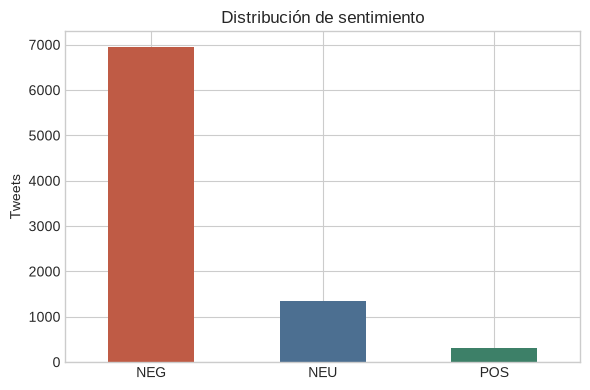

In [4]:
ax = sent_counts.plot(kind="bar", figsize=(6, 4), color=["#bf5b45", "#4c6f91", "#3d8068"])
ax.set_title("Distribución de sentimiento")
ax.set_xlabel("")
ax.set_ylabel("Tweets")
plt.xticks(rotation=0)
plt.tight_layout()

## 5. Identificación y Análisis de Insultos

Detectamos y analizamos las expresiones ofensivas más frecuentes en los comentarios.

Creemos que hay mucho para explorar a partir de las keypharses detectadas. En principio reflejan un poco nuestra intuición a partir de la lectura de algunos comentarios y de la distribución de sentimientos encontrada, muchos de los bigramas más frecuentes tienen una fuerte carga negativa: "obesidad_morbida", "gordo_obeso". Observamos también algunos insultos.

Por medio de la medida pmi encontramos otros interesantes como "higado_graso", "resistencia_insulina", "permite_agresion". Los bigramas encontrados con esta métrica varían mucho modificando el filtro por frecuencia de tokens, nos queda averiguar cómo definir algún criterio para determinar a partir de qué frecuencia filtrar.

In [5]:
host_counts = df["hs_spanlp"].value_counts()
pd.DataFrame({"tweets": host_counts, "porcentaje": percent(host_counts)})

,tweets,porcentaje
hs_spanlp,,
False,5105,59.37
True,3493,40.63


In [6]:
pd.crosstab(df["pysentimiento"], df["hs_spanlp"], normalize="index").round(3)

hs_spanlp,False,True
pysentimiento,,
NEG,0.576,0.424
NEU,0.672,0.328
POS,0.645,0.355


## 6. Relación entre Longitud de Comentarios y Sentimiento

Analizamos si existe una relación entre la extensión de los comentarios y el sentimiento expresado.

In [7]:
assigned = df[df["topic"] != -1].copy()
sentiment_topic = pd.crosstab(assigned["topic"], assigned["pysentimiento"], normalize="index").round(3)
sentiment_topic.head(20)

pysentimiento,NEG,NEU,POS
topic,,,
0,0.866,0.096,0.038
1,0.892,0.091,0.017
2,0.863,0.116,0.021
3,0.669,0.286,0.046
4,0.800,0.172,0.028
5,0.862,0.107,0.031
6,0.833,0.147,0.020
7,0.897,0.091,0.011
8,0.830,0.117,0.053


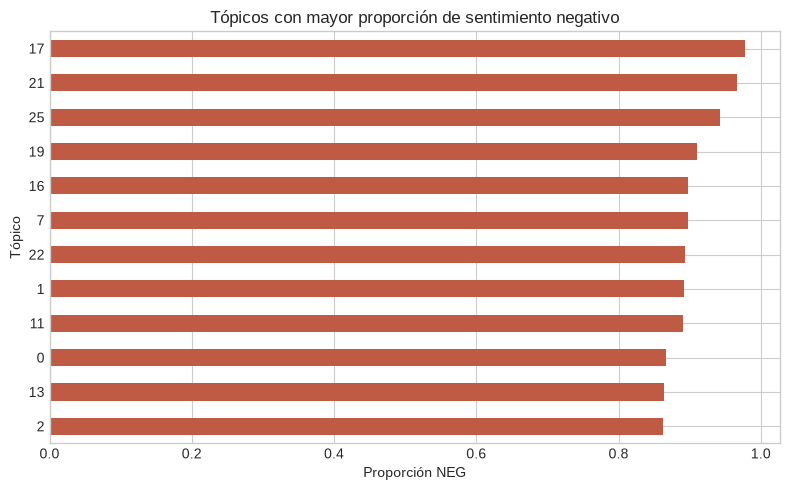

In [8]:
if "NEG" in sentiment_topic.columns:
    top_negative = sentiment_topic["NEG"].sort_values(ascending=False).head(12)
    ax = top_negative.sort_values().plot(kind="barh", figsize=(8, 5), color="#bf5b45")
    ax.set_title("Tópicos con mayor proporción de sentimiento negativo")
    ax.set_xlabel("Proporción NEG")
    ax.set_ylabel("Tópico")
    plt.tight_layout()

## 8. Análisis Adicional: Patrones Temporales y Engagement

Exploramos patrones temporales y la relación entre sentimiento y engagement (likes, retweets, etc.).

In [9]:
host_topic = pd.crosstab(assigned["topic"], assigned["hs_spanlp"], normalize="index").round(3)
host_topic.sort_values(True, ascending=False).head(15) if True in host_topic.columns else host_topic.head(15)

hs_spanlp,False,True
topic,,
22,0.380,0.620
21,0.402,0.598
5,0.450,0.550
24,0.486,0.514
7,0.490,0.510
17,0.493,0.507
12,0.494,0.506
8,0.495,0.505
25,0.500,0.500


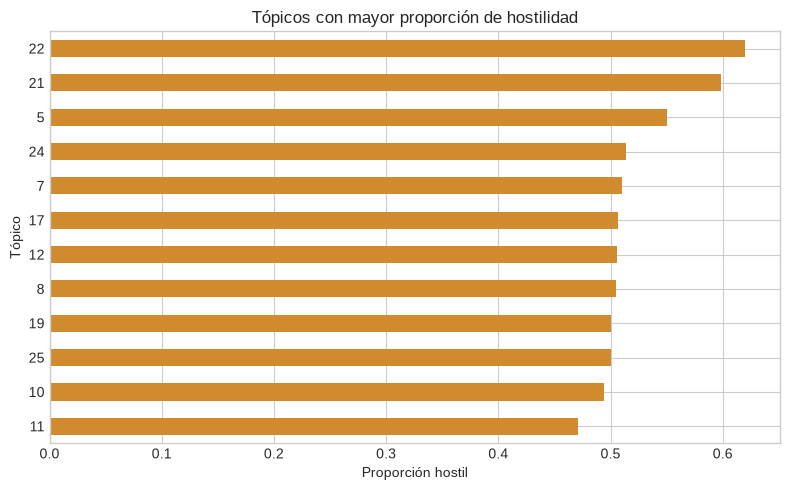

In [10]:
if True in host_topic.columns:
    ax = host_topic[True].sort_values(ascending=False).head(12).sort_values().plot(kind="barh", figsize=(8, 5), color="#d08b2f")
    ax.set_title("Tópicos con mayor proporción de hostilidad")
    ax.set_xlabel("Proporción hostil")
    ax.set_ylabel("Tópico")
    plt.tight_layout()

## 8. Conclusiones y Insights

Resumen de los hallazgos principales del análisis de sentimientos.

Algunos hallazgos que nos parecieron interesantes son:
- El 25% de los usuarios tiene 5 o más tweets publicados.
- Encontramos que muchos tweets no son pertinentes y podrían considerarse ruidos, por lo que nos interesaría analizar y entender mejor cómo se construyo la base de datos.
- En esta primera exploración hemos visto que el discurso de odio esta presente de manera recurrente en muchos comentarios y nos gustaría entender mejor que ideas se expresan en estos posteos.
- Encontramos que, al parecer, más del 80% de los posteos son negativos.

Más que hipótesis se nos ocurren líneas de análisis o tipos de análisis que podríamos realizar. Nos interesaría profundizar la percepción social de la temática y como se construye esa percepción en los distintos tópicos alrededor de los cuales giran los discursos sobre la obesidad. En un sentido general, hemos observado que la conversación se da en torno a por ejemplo ciertos programas televisivos como cuestión de peso o gran hermano, otros tienen que ver con el deporte, la salud es un tema que aparece de manera frecuente, así como también se observan muchos comentarios que son autorreflexivos por parte de su autor. Nos preguntamos cuáles son las ideas centrales que se manifiestan en la conversación en Twitter acerca de la obsedidad? En particular lo subyacente a los discursos, los conceptos y asociaciones que sustentan las ideas expresadas en los comentarios.

Para ello pensamos que sería interesante trabajar con algún algoritmo de clustering para encontrar tópicos y también construir un knowledge graph a partir de estos datos con el objetivo de intentar descubrir esas asociaciones subyacentes a los discursos.

Pensamos que algunas variables que sería interesante incorporar (dependiendo de lo que finalmente vayamos a hacer) son:
- el sentimiento de los comentarios
- variable que indique hatespeech o insultos
- una que defina la temática, como resultado de aplicar un algoritmo de clustering

Por último consideramos fundamental incorporar:
- limpieza de comentarios irrelevantes
- limpieza de palabras como 'link_url'

In [11]:
monthly_sentiment = pd.crosstab(
    pd.to_datetime(df["date"], errors="coerce").dt.to_period("M").astype(str),
    df["pysentimiento"],
    normalize="index",
).round(3)
monthly_sentiment.tail(12)

pysentimiento,NEG,NEU,POS
date,,,
2024-01,0.847,0.122,0.031
2024-02,0.841,0.128,0.031
2024-03,0.775,0.187,0.038
2024-04,0.818,0.151,0.031
2024-05,0.782,0.188,0.030
2024-06,0.832,0.131,0.037
2024-07,0.809,0.147,0.043
2024-08,0.811,0.154,0.036
2024-09,0.817,0.146,0.037


In [12]:
province_hostility = (
    df.assign(pcia_unica=df["pcia_unica"].fillna("sin_dato"))
    .groupby("pcia_unica")["hs_spanlp"]
    .agg(tweets="size", proporcion_hostil="mean")
    .query("tweets >= 20")
    .sort_values("proporcion_hostil", ascending=False)
)
province_hostility.head(15)

,tweets,proporcion_hostil
pcia_unica,,
entre rios,43,0.465116
tierra del fuego,72,0.458333
santa cruz,45,0.444444
rio negro,80,0.425000
caba,411,0.413625
sin_dato,742,0.411051
buenos aires,6815,0.407190
santa fe,107,0.383178
tucuman,50,0.360000


> Nota de curaduría para portfolio: esta sección cruza las etiquetas ya calculadas con los tópicos, manteniendo la lectura ética de que son señales automáticas y no anotaciones humanas definitivas.